In [1]:
import os
import torch
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    SegformerImageProcessor, 
    SegformerForSemanticSegmentation, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)

In [2]:

IMAGE_DIR = "./data/JPEGImages"
MASK_DIR = "./data/SegmentationClass"
MODEL_ID = "nvidia/mit-b0"  # Small, fast, and accurate for most tasks

ID2LABEL = {0: "background", 1: "filth"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

In [3]:
# Get all image filenames
all_filenames = sorted([
    f for f in os.listdir(IMAGE_DIR) 
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])

# 80/20 Split
train_files, val_files = train_test_split(
    all_filenames, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

print(f"Total images: {len(all_filenames)}")
print(f"Training on: {len(train_files)}")
print(f"Validating on: {len(val_files)}")

Total images: 99
Training on: 79
Validating on: 20


In [4]:
def run_sanity_check(filenames, img_dir, mask_dir):
    print(f"Starting check on {len(filenames)} files...")
    issues = 0
    
    for fname in filenames:
        img_path = os.path.join(img_dir, fname)
        mask_name = os.path.splitext(fname)[0] + ".png"
        mask_path = os.path.join(mask_dir, mask_name)
        
        # 1. Check if files exist
        if not os.path.exists(img_path):
            print(f"MISSING IMAGE: {img_path}")
            issues += 1
            continue
        if not os.path.exists(mask_path):
            print(f"MISSING MASK: {mask_path}")
            issues += 1
            continue
            
        try:
            img = Image.open(img_path)
            mask = Image.open(mask_path)
            
            # 2. Check if dimensions match
            if img.size != mask.size:
                print(f"SIZE MISMATCH: {fname} (Img: {img.size}, Mask: {mask.size})")
                issues += 1
            
            # 3. Check mask values (Ensure they aren't all zero)
            mask_array = np.array(mask)
            unique_vals = np.unique(mask_array)
            if len(unique_vals) <= 1:
                # Warning only: some images might actually only have background
                pass 
                
        except Exception as e:
            print(f"CORRUPT FILE: {fname} - {e}")
            issues += 1

    if issues == 0:
        print("✅ Sanity check passed! Your dataset is ready for training.")
    else:
        print(f"❌ Found {issues} issues. Please fix them before training.")

# Run it
run_sanity_check(all_filenames, IMAGE_DIR, MASK_DIR)

Starting check on 99 files...


KeyboardInterrupt: 

In [ ]:
class SegformerDataset(Dataset):
    def __init__(self, filenames, img_dir, mask_dir, processor):
        self.filenames = filenames
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.processor = processor

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        
        image = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        mask_name = os.path.splitext(fname)[0] + ".png"
        mask = Image.open(os.path.join(self.mask_dir, mask_name)).convert("L")

        # --- FIX START: SANITIZE MASK VALUES ---
        mask_array = np.array(mask)
        
        # Option A: If your data is just Background vs Filth, 
        # make everything that isn't 0 into 1.
        mask_array[mask_array > 0] = 1
        
        # Option B (Use this if you have noisy edges): 
        # Only treat strong signals (e.g. > 128) as filth, ignore weak noise
        # mask_array = (mask_array > 128).astype(np.uint8)
        
        # Convert back to PIL for the processor
        mask = Image.fromarray(mask_array)
        # --- FIX END ---

        encoded_inputs = self.processor(
            image, 
            mask, 
            return_tensors="pt"
        )
        
        for k, v in encoded_inputs.items():
            encoded_inputs[k] = v.squeeze(0)
            
        return encoded_inputs

In [ ]:
processor = SegformerImageProcessor.from_pretrained(MODEL_ID)
processor.do_reduce_labels = False 

train_dataset = SegformerDataset(train_files, IMAGE_DIR, MASK_DIR, processor)
val_dataset = SegformerDataset(val_files, IMAGE_DIR, MASK_DIR, processor)

model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_ID,
    num_labels=len(ID2LABEL),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

/home/ugnius/Documents/KTU/IV-kursas/II-semestras/BBP/V2/model_tests/.venv/lib/python3.13/site-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

In [ ]:
device = torch.device("cuda")
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Usage: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_ID,
    num_labels=len(ID2LABEL),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

model.to(device)

training_args = TrainingArguments(
    output_dir="./segformer-finetuned-results",
    learning_rate=6e-5,
    num_train_epochs=50,             # Set this high (e.g. 50 or 100)
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    
    eval_strategy="epoch",           # Evaluate every epoch
    save_strategy="epoch",           # Save every epoch (must match eval_strategy)
    load_best_model_at_end=True,     # Load the best checkpoint when finished
    metric_for_best_model="loss",    # Watch the validation loss
    greater_is_better=False,         # Lower loss is better
    
    save_total_limit=2,              # Only keep the last 2 checkpoints to save space
    logging_steps=10,
    fp16=True,                       # Keep True for your RTX 3070
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

trainer.train()
trainer.save_model("./final_model")             # Saves model weights
processor.save_pretrained("./final_model")      # Saves the missing preprocessor_config.json

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3070 Laptop GPU
Memory Usage: 0.06 GB


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Epoch,Training Loss,Validation Loss
1,0.559426,0.589400
2,0.407686,0.461095
3,0.339091,0.370924
4,0.306120,0.322885
5,0.291159,0.296846
6,0.268442,0.273032
7,0.255670,0.269558
8,0.247856,0.263744
9,0.239349,0.252161
10,0.216284,0.267634


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./final_model/preprocessor_config.json']

Loading model from ./final_model...
Running on: cuda
✅ Loaded processor from ./final_model


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

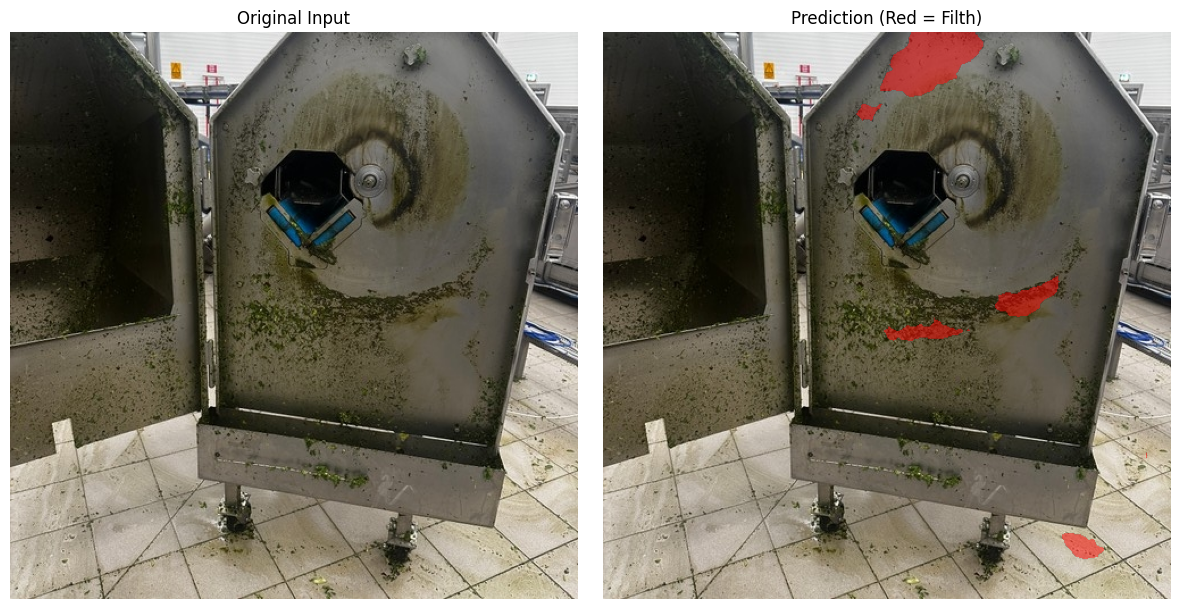

In [ ]:
import torch
from torch import nn
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# --- CONFIGURATION ---
MODEL_DIR = "./final_model"      # Your saved folder
IMAGE_PATH = "./test_image10.jpg"  # Change to your image path
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model from {MODEL_DIR}...")
print(f"Running on: {DEVICE}")

# --- 1. SMART LOAD ---
# Try to load processor from local folder; if missing, use default
try:
    processor = SegformerImageProcessor.from_pretrained(MODEL_DIR)
    print("✅ Loaded processor from ./final_model")
except OSError:
    print("⚠️ Processor config not found in ./final_model. Fallback to nvidia/mit-b0 (This is fine).")
    processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b0")

processor.do_reduce_labels = False 

# Load the fine-tuned weights
model = SegformerForSemanticSegmentation.from_pretrained(MODEL_DIR)
model.to(DEVICE)
model.eval()

# --- 2. PREDICTION FUNCTION ---
def predict(image_path):
    # Load Image
    image = Image.open(image_path).convert("RGB")
    
    # Preprocess
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    
    # Forward Pass
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Upsample logits to original image size
    # (B, C, H, W) -> (C, H, W)
    logits = outputs.logits
    upsampled_logits = nn.functional.interpolate(
        logits,
        size=image.size[::-1], # (height, width)
        mode="bilinear",
        align_corners=False,
    )
    
    # Argmax to get class indices
    pred_seg = upsampled_logits.argmax(dim=1)[0]
    return image, pred_seg.cpu().numpy()

# --- 3. RUN & VISUALIZE ---
if not os.path.exists(IMAGE_PATH):
    print(f"❌ Error: Image not found at {IMAGE_PATH}")
else:
    original, mask = predict(IMAGE_PATH)

    # Create Red Overlay for Class 1 (Filth)
    mask_overlay = np.zeros((mask.shape[0], mask.shape[1], 4))
    # Red color: [R=1, G=0, B=0, Alpha=0.5]
    mask_overlay[mask == 1] = [1, 0, 0, 0.5]

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(original)
    ax[0].set_title("Original Input")
    ax[0].axis("off")
    
    ax[1].imshow(original)
    ax[1].imshow(mask_overlay)
    ax[1].set_title("Prediction (Red = Filth)")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()